# 20 - Ensemble Methods

> 📘 **Instructor Curriculum**

### The story

One doctor reads your report and says *"you are fine"*.

Would you bet your life on that one opinion? Most people ask a second
doctor. Maybe a third. If four out of five say the same thing, you relax.

That is this whole notebook.

```
   one model      =  one doctor
   an ENSEMBLE    =  a panel of models, answering together
```

**Why is a panel better than one expert?**

Because every model is wrong in its own way. One tree gets confused by a
strange row. Another tree gets confused by a different row. When you count
their answers, the mistakes do not line up, so they cancel each other out.
The thing they all agree on is usually the truth.

You already trust this idea in Java. One service instance can go bad. Five
instances behind a load balancer, and one bad instance does not decide the
response.

### Three ways to build the panel

| way | how the panel is built | in this notebook |
| --- | --- | --- |
| **Bagging** | many models learn **at the same time**, each on a different random slice of the data, then they vote | `RandomForestClassifier`, `RandomForestRegressor` |
| **Boosting** | models learn **one after another**, each new one works on what the previous one got wrong | `AdaBoostClassifier`, `GradientBoostingClassifier` |
| **Voting** | **you** pick different kinds of models yourself, then they vote | `VotingClassifier` |

In everyday words:

- **Bagging** - five people read five different chapters, then discuss.
- **Boosting** - one person studies, fails question 7, studies question 7
  again, and again, until the weak spots are gone.
- **Voting** - a doctor, a chemist and a nurse in one room.

```
   BAGGING (all at once)              BOOSTING (a chain)

   data --> tree 1 \                  data --> m1 --> what it got wrong
   data --> tree 2  >-- vote                    |
   data --> tree 3 /                            v
        (100 trees)                            m2 --> what is still wrong
                                                |
                                                v
                                               m3 --> final answer
```

In [1]:
import pandas as pd
from sklearn.datasets import load_iris
iris = load_iris()
table = pd.DataFrame(iris.data,columns=iris.feature_names)
table.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [2]:
table['target'] = iris.target
table.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


### The data, in one line

150 flowers. 4 measurements each. 3 species, written as `0`, `1`, `2`.

`x` = the four measurements. `y` = the species you want to predict.

The split gives **105 rows to learn from and 45 rows for the exam**.
45 is a small exam. One flower is worth 2.2%. Keep that in mind when you
read every score below.

In [3]:
x = table.drop(['target'], axis='columns')
y = iris.target

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.30, random_state = 0)

## 1. Random Forest - the bagging family

### Why it exists

A single decision tree memorises. Let it run free and it keeps splitting
until every leaf is pure. It looks brilliant on the data it saw, then trips
on the first new row.

The fix is not a smarter tree. The fix is **many trees, each wrong in a
different way**.

### How the forest keeps its trees different

Two bits of randomness:

1. **Different rows.** Each tree gets its own random sample of the 105
   training rows, picked with repeats. So tree 1 never sees exactly what
   tree 7 sees.
2. **Different columns.** At each split a tree may only look at a few of
   the 4 measurements, not all of them. This stops one very strong column
   (petal length) from being the first question in all 100 trees.

Then the 100 trees vote. Majority wins.

```
   105 training rows
      |- random sample --> tree 1 --> says 2
      |- random sample --> tree 2 --> says 2
      |- random sample --> tree 3 --> says 1
      ...                              (100 trees)
                              vote --> answer: 2
```

### Where it is used

Credit scoring, churn, fraud, "which customers will renew". Anywhere you
have a table of columns and need a solid answer without much tuning. On
tabular data this is the normal first thing to try.

### The syntax

- `n_estimators=100` - how many trees to grow. More trees = steadier
  answer, slower training. Raising it does not overfit, it only costs time.
- `.fit(X_train, y_train)` - grows all 100 trees.
- `.score(X_test, y_test)` - the share of the 45 test flowers it got right.

In [7]:
from sklearn.ensemble import RandomForestClassifier
classifier = RandomForestClassifier(n_estimators=100)
classifier.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [8]:
classifier.score(X_test,y_test)

0.9777777777777777

`0.9777` means **44 correct out of 45**. One flower wrong.

## 2. AdaBoost - the boosting family

### Why it exists

The forest builds all its trees at once, and no tree knows what the others
got wrong. Nobody is working on the hard cases.

Boosting has the opposite habit. It builds one model, looks at the rows it
got wrong, and then builds the next model **paying extra attention to
exactly those rows**.

### The story

A teacher gives a test. Five students fail question 7.

She does not repeat the whole syllabus. She marks question 7 in red and
teaches that one again. Next test, fewer people fail it. She repeats this
100 times.

That red mark is a **weight**. Every training row carries one.

- Row predicted right -> its weight goes down. Move on.
- Row predicted wrong -> its weight goes up. The next model must fix it.

At the end each small model also gets a **vote weight**. A model that was
accurate speaks loudly. A model that was barely better than a coin toss
whispers. The final answer is that weighted vote.

```
   round 1: all rows equal        --> model 1 --> 8 rows wrong
   round 2: those 8 rows heavy    --> model 2 --> 3 rows wrong
   round 3: those 3 rows heavy    --> model 3 --> ...

   final answer = loud vote of the good models
                + soft vote of the weak ones
```

### The syntax

- `estimator=DecisionTreeClassifier(max_depth=3)` - the small model that
  gets repeated. Depth 3 means it may ask only 3 questions. Boosting wants
  a **weak** learner on purpose. Hand it a full deep tree and there is no
  mistake left for the next round to fix.
- `n_estimators=100` - how many rounds of *learn -> look at mistakes ->
  learn again*. Here it is the length of a chain, not the size of a crowd.

In [11]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

In [16]:
classifier1 = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3), n_estimators=100)

In [17]:
classifier1.fit(X_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...r(max_depth=3)
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",100
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](3,)","[0,1,2]"
estimator_ estimator_: estimatorThe base estimator from which the ensemble is grown... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,DecisionTreeClassifier,DecisionTreeC...r(max_depth=3)
estimator_errors_ estimator_errors_: ndarray of floatsClassification error for each estimator in the boostedensemble.,"ndarray[float64](100,)","[0.02,0.01,0.01,...,1. ,1. ,1. ]"
estimator_weights_ estimator_weights_: ndarray of floatsWeights for each estimator in the boosted ensemble.,"ndarray[float64](100,)","[4.63,5.03,5.9 ,...,0. ,0. ,0. ]"
estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators.,list,"[DecisionTreeC...ate=330203757), DecisionTreeC...ate=228652277), DecisionTreeC...ate=449026551), DecisionTreeC...te=2026386999), ...]"
"feature_importances_ feature_importances_: ndarray of shape (n_features,)The impurity-based feature importances if supported by the``estimator`` (when based on decision trees).Warning: impurity-based feature importances can be misleading forhigh cardinality features (many unique values). See:func:`sklearn.inspection.permutation_importance` as an alternative.","ndarray[float64](4,)","[0.13,0.15,0.27,0.45]"


In [18]:
classifier1.score(X_test,y_test)

0.9777777777777777

Also **44 out of 45**. Exactly the same as the forest.

Iris is an easy dataset - three flower types that separate cleanly. On easy
data every decent model lands in the same place. Ensembles show their real
gap on messy data.

## 3. Gradient Boosting - boosting by chasing the leftover

### Why it exists

AdaBoost fixes mistakes by making rows heavier.

Gradient Boosting fixes them a different way: each new tree predicts the
**leftover error** of everything built so far.

### The story

You guess a house price: 50 lakh. The real price is 62.

The leftover is `+12`. You do not throw your guess away. You train a second
small model whose only job is to predict that `+12`. Now your answer is
`50 + 12 = 62`. Then you look at the new leftover and build a third model
for that one.

Each tree is an apology for the answer before it.

### `learning_rate` - the one setting to really understand

You do not add the whole correction. You add a slice of it.

```
   learning_rate = 1.00  ->  50 + 12.00 = 62.00   one big jump, easy to overshoot
   learning_rate = 0.01  ->  50 +  0.12 = 50.12   one tiny careful step
```

Small rate = careful steps = you need many more trees to arrive.

Your cell uses `learning_rate=0.01` with `n_estimators=100`, so 100 very
small steps. On a harder dataset that would still be far from the target.
Iris is easy enough that it gets there anyway.

Rule of thumb: **lower the rate, raise the trees.** The two pull against
each other.

### Where it is used

This family, and its faster cousins XGBoost and LightGBM, wins most
tabular competitions and runs a lot of real risk and ranking systems.
Slower to train than a forest, usually a little more accurate, and much
more sensitive to its settings.

In [19]:
from sklearn.ensemble import GradientBoostingClassifier

In [20]:
clf = GradientBoostingClassifier(n_estimators=100, learning_rate=0.01)

In [21]:
clf.fit(X_train, y_train)

,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.01
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"init init: estimator or 'zero', default=NoneAn estimator object that is used to c

In [22]:
clf.score(X_test,y_test)

0.9777777777777777

## 4. Voting Classifier - a panel of different experts

Forest and boosting both build **one kind of model, many times**.

Voting is different. You choose several **different algorithms** yourself
and let them vote.

Why bother? Because a tree, an SVM and a KNN are wrong in very different
ways. A tree cuts the space into boxes. An SVM draws one clean boundary.
KNN just asks the nearest neighbours. When three minds that different
agree, the answer is worth trusting.

### The syntax

`estimators` is a list of `(name, model)` pairs. The name is only a label
so you can pull that model out later - like a bean name in Spring.

In [23]:
from sklearn.ensemble import VotingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

In [25]:
estimators = [ 
    ('m1',RandomForestClassifier(n_estimators=5)),
    ('m2',SVC(probability=True)),
    ('m3',KNeighborsClassifier(n_neighbors=3)),
    ('m4',AdaBoostClassifier(estimator=DecisionTreeClassifier() ,n_estimators=5)),
    ('m5',LogisticRegression()) 
]

### `voting='hard'` - a show of hands

Each model says one class. Count the hands. Most hands wins.

```
   m1 says 2
   m2 says 2
   m3 says 1     -->  class 2 wins, 4 votes to 1
   m4 says 2
   m5 says 2
```

A model that is 51% sure and a model that is 99% sure both raise exactly
one hand. Hard voting throws confidence away.

In [26]:
final = VotingClassifier(estimators=estimators, voting='hard')

In [27]:
final.fit(X_train, y_train)

/Users/kaliprasad/Documents/MACHINE_LEARNING/pizza_env/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('m1', ...), ('m2', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'hard'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](3,)","[0,1,2]"
"estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators as defined in ``estimators``that are not 'drop'. Note that sub-estimators are always fitted oninteger-encoded labels (see ``le_`` attribute). When ``y`` containsnon-integer class labels (e.g. strings), use ``le_.inverse_transform``to map predictions back to the original label space.",list,"[RandomForestC..._estimators=5), SVC(probability=True), KNeighborsCla...n_neighbors=3), AdaBoostClass..._estimators=5), ...]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimators expose such an attribute when fit... versionadded:: 1.0","ndarray[object](4,)","['sepal length (cm)','sepal width (cm)','petal length (cm)', 'petal width (cm)']"
le_ le_: :class:`~sklearn.preprocessing.LabelEncoder`Transformer used to encode the labels during fit and decode duringprediction. Sub-estimators in ``estimators_`` are fitted on theinteger-encoded labels produced by this encoder.,LabelEncoder,LabelEncoder()


In [28]:
for m in (final.estimators_):
    print (m.score(X_test,y_test))
    

0.9777777777777777
0.9777777777777777
0.9777777777777777
0.9777777777777777
0.9777777777777777


`final.estimators_` - note the underscore at the end. That is the sklearn
habit you have seen before: **a name ending in `_` only exists after
`fit()`**. It holds the five trained models.

Without the underscore, `final.estimators` is just the list of untrained
recipes you typed.

All five print `0.9777`. Five different algorithms, the same 44 out of 45.
Another sign that iris is easy - not that the five models are the same.

In [29]:
final.transform(X_test)

array([[2, 2, 2, 2, 2],
       [1, 1, 1, 1, 1],
       [0, 0, 0, 0, 0],
       [2, 2, 2, 2, 2],
       [0, 0, 0, 0, 0],
       [2, 2, 2, 2, 2],
       [0, 0, 0, 0, 0],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [2, 2, 2, 2, 2],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [0, 0, 0, 0, 0],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0],
       [2, 2, 2, 2, 2],
       [1, 1, 1, 1, 1],
       [0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0],
       [2, 2, 2, 2, 2],
       [0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [0, 0, 0, 0, 0],
       [2, 2, 2, 2, 2],
       [1, 1, 1, 1, 1],
       [0, 0, 0, 0, 0],
       [2, 2, 2, 2, 2],
       [2, 2, 2, 2, 2],
       [1, 1, 1, 1, 1],
       [0, 0, 0, 0, 0],
       [2, 2, 2, 2, 2],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [2, 2, 2, 2, 2],
       [0, 0, 0,

`transform()` shows you what the vote actually looked like.

With hard voting you get **one column per model**, filled with class labels:

```
   [2, 2, 2, 2, 2]   <- all five said class 2
   [1, 1, 1, 1, 1]   <- all five said class 1
```

Useful for debugging. When the panel is wrong, you can see which member
dragged it there.

In [31]:
estimators = [ 
    ('m1',RandomForestClassifier(n_estimators=5)),
    ('m2',SVC(probability=True)),
    ('m3',KNeighborsClassifier(n_neighbors=3)),
    ('m4',AdaBoostClassifier(estimator=DecisionTreeClassifier() ,n_estimators=5)),
    ('m5',LogisticRegression()) 
]

### `voting='soft'` - everyone says how sure they are

Now each model gives a probability for every class. You average those
probabilities and take the highest one.

```
   class            0      1      2
   m1             0.00   0.20   0.80
   m2             0.01   0.03   0.96
   m3             0.00   0.00   1.00
   m4             0.24   0.24   0.51
   m5             0.00   0.06   0.94
   ------------------------------------
   average        0.05   0.11   0.84   -->  class 2
```

A confident model now pulls harder than an unsure one. Soft voting is
usually a bit better, on one condition: the probabilities must be honest.

That is why `SVC(probability=True)` is there. A plain SVM only tells you
which side of the line you are on, not a probability, so `probability=True`
fits an extra step that turns distance into probability.

Your output shows a `FutureWarning`: sklearn is moving that job to
`CalibratedClassifierCV(SVC(), ensemble=False)`. The code still runs today.

In [32]:
final = VotingClassifier(estimators=estimators, voting='soft')
final.fit(X_train, y_train)

/Users/kaliprasad/Documents/MACHINE_LEARNING/pizza_env/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('m1', ...), ('m2', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](3,)","[0,1,2]"
"estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators as defined in ``estimators``that are not 'drop'. Note that sub-estimators are always fitted oninteger-encoded labels (see ``le_`` attribute). When ``y`` containsnon-integer class labels (e.g. strings), use ``le_.inverse_transform``to map predictions back to the original label space.",list,"[RandomForestC..._estimators=5), SVC(probability=True), KNeighborsCla...n_neighbors=3), AdaBoostClass..._estimators=5), ...]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimators expose such an attribute when fit... versionadded:: 1.0","ndarray[object](4,)","['sepal length (cm)','sepal width (cm)','petal length (cm)', 'petal width (cm)']"
le_ le_: :class:`~sklearn.preprocessing.LabelEncoder`Transformer used to encode the labels during fit and decode duringprediction. Sub-estimators in ``estimators_`` are fitted on theinteger-encoded labels produced by this encoder.,LabelEncoder,LabelEncoder()


In [33]:
for m in (final.estimators_):
    print(m.score(X_test,y_test))

0.9777777777777777
0.9777777777777777
0.9777777777777777
0.9777777777777777
0.9777777777777777


In [34]:
final.transform(X_test)

array([[0.00000000e+00, 2.00000000e-01, 8.00000000e-01, 9.78610770e-03,
        2.83979510e-02, 9.61815941e-01, 0.00000000e+00, 0.00000000e+00,
        1.00000000e+00, 2.42895311e-01, 2.42895311e-01, 5.14209378e-01,
        1.32030906e-04, 5.99153243e-02, 9.39952645e-01],
       [0.00000000e+00, 1.00000000e+00, 0.00000000e+00, 1.15279441e-02,
        9.78272162e-01, 1.01998937e-02, 0.00000000e+00, 1.00000000e+00,
        0.00000000e+00, 2.42895311e-01, 5.14209378e-01, 2.42895311e-01,
        1.33966257e-02, 9.56943671e-01, 2.96597035e-02],
       [1.00000000e+00, 0.00000000e+00, 0.00000000e+00, 9.66515301e-01,
        1.99623766e-02, 1.35223227e-02, 1.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 5.14209378e-01, 2.42895311e-01, 2.42895311e-01,
        9.82917312e-01, 1.70826318e-02, 5.59601140e-08],
       [0.00000000e+00, 0.00000000e+00, 1.00000000e+00, 1.03815370e-02,
        5.22049936e-03, 9.84397964e-01, 0.00000000e+00, 0.00000000e+00,
        1.00000000e+00, 2.42895311e-0

The soft `transform()` output is wider: **15 columns = 5 models x 3
classes**. Read each row in groups of three, exactly like the table above.

## 5. Random Forest Regressor - the same forest, for numbers

Everything above predicted a class, so voting made sense. For a number
there is nothing to vote on, so the forest **averages** instead.

```
   classification  ->  100 trees, the majority class wins
   regression      ->  100 trees, the mean of their 100 numbers
```

Nothing else changes. Same random rows, same random columns, same idea.

`make_regression(n_features=1, noise=2, n_samples=10000)` builds 10000 fake
points sitting on a straight line with a little noise, so you can see the
shape before you fit anything.

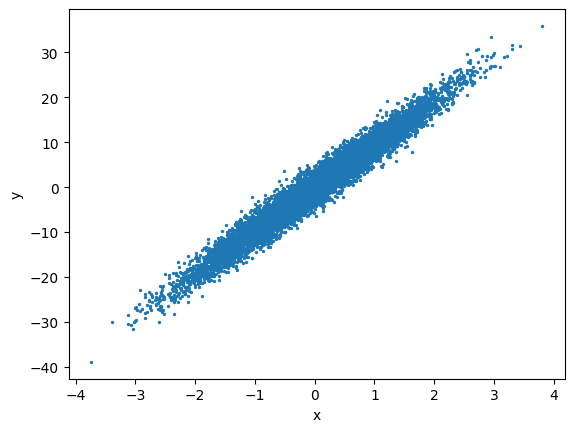

In [35]:
from sklearn.datasets import make_regression
x,y = make_regression(n_features=1, noise=2, n_samples=10000,random_state=0)
import matplotlib.pyplot as plt
plt.scatter(x,y,s=2)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [36]:
from sklearn.ensemble import RandomForestRegressor
reg = RandomForestRegressor(n_estimators=100)
reg.fit(x, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the numb

In [37]:
reg.score(x, y)

0.9911716974219119

`0.991` here is **R²**: the model explains about 99% of the movement in `y`.

One honest warning. This line scores on `x, y` - **the same data the forest
learned from**. That is the model marking its own homework. A forest can
nearly always score high on rows it has memorised.

The `0.977` scores earlier were measured on `X_test`, which those models had
never seen. Only those are real. To get a true number here, split first and
score on the test part.

## Putting it together

| model | family | how it learns | score |
| --- | --- | --- | --- |
| `RandomForestClassifier` | bagging | 100 trees at once, random rows + random columns, majority vote | 0.978 |
| `AdaBoostClassifier` | boosting | 100 depth-3 trees in a chain, wrong rows get heavier | 0.978 |
| `GradientBoostingClassifier` | boosting | 100 trees, each predicts the leftover error, in tiny 0.01 steps | 0.978 |
| `VotingClassifier(hard)` | voting | 5 different algorithms, one vote each | 0.978 |
| `VotingClassifier(soft)` | voting | the same 5, probabilities averaged | 0.978 |
| `RandomForestRegressor` | bagging | 100 trees, their numbers averaged | 0.991 R², but on training data |

Everything ties at 44 out of 45. **That is the dataset talking, not the
models.** Iris has three clean species; one flower sits on the border and
every model misses that same one.

Where they really differ:

| what you want | pick |
| --- | --- |
| a fast, safe first model with little tuning | Random Forest |
| the last bit of accuracy, and you have time to tune | Gradient Boosting |
| you already have 3-4 good models of different kinds | Voting, soft |
| noisy data with odd outliers | Random Forest - boosting chases noisy rows and can learn the noise |

**If you remember only one thing...**

**Bagging builds a crowd. Boosting builds a chain.**
A crowd cancels out unstable guesses. A chain keeps fixing what is still
wrong. Both beat one model, for two completely different reasons.